### Exploring shapely

In [106]:
import shapely

p = shapely.Point(1,2)

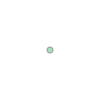

In [107]:
p

That isn't a placeholder, the point is being displayed on the screen.

In [108]:
poly = shapely.Polygon([(0,0),(2,0),(2,3),(0,3),(0,0)])
poly.contains(p)

True

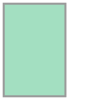

In [109]:
poly

There are various points that can stand in for the whole object:  `centroid` and `representative_point`.

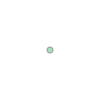

In [110]:
poly.centroid

In [111]:
print(poly.centroid)

POINT (1 1.5)


In [112]:
type(poly.centroid)

shapely.geometry.point.Point

In [113]:
rp = poly.representative_point()
print(rp)

POINT (1 1.5)


In [114]:
type(rp)

shapely.geometry.point.Point

In [115]:
q = shapely.Point(4,5)
q.distance(p)

4.242640687119285

A point has an attribute `coords` whose type is:

In [116]:
type(p.coords)

shapely.coords.CoordinateSequence

An easy way to get at a `CoordinateSequence` is to turn it into a `list`:

In [117]:
list(p.coords)

[(1.0, 2.0)]

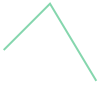

In [118]:
r = shapely.Point(7,0)
LS = shapely.LineString([p,q,r])
LS

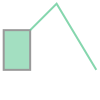

In [119]:
LS.union(poly)

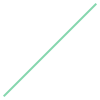

In [120]:
LS.intersection(poly)

In [121]:
type(LS)

shapely.geometry.linestring.LineString

In [122]:
type(LS.coords)

shapely.coords.CoordinateSequence

In [123]:
list(LS.coords)

[(1.0, 2.0), (4.0, 5.0), (7.0, 0.0)]

There is a much more complicated way to dig down into a `CoordinateSequence`:

In [124]:
LS.coords[:][0]

(1.0, 2.0)

The brackets colon notation in Python means to make a copy of a list.  Here it converts a `CoordinateSequence` object into a `list`.

In [125]:
type(LS.coords[:])

list

Of course, a list can have more than one element.  Hence the `[0]`.

In [126]:
print(poly)

POLYGON ((0 0, 2 0, 2 3, 0 3, 0 0))


Notice the double parentheses.  The reason for this is that it is allowed for a polygon to have holes.  (For example, a state might contain lakes).

In [127]:
border = [(-180, 90), (-180, -90), (180, -90), (180, 90)]
holes = [[(-170, 80), (-170, -80), (170, -80), (170, 80)]]
frame = shapely.Polygon(shell=border, holes=holes)
print(frame)

POLYGON ((-180 90, -180 -90, 180 -90, 180 90, -180 90), (-170 80, -170 -80, 170 -80, 170 80, -170 80))


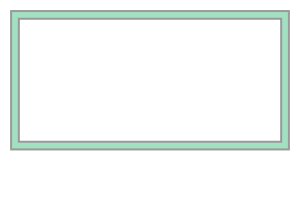

In [128]:
frame

In [129]:
print(f"Polygon centroid: {frame.centroid}")
print(f"Polygon Area: {frame.area}")
print(f"Polygon Bounding Box: {frame.bounds}")
print(f"Polygon Exterior: {frame.exterior}")
print(f"Polygon Exterior Length: {frame.exterior.length}")

Polygon centroid: POINT (0 0)
Polygon Area: 10400.0
Polygon Bounding Box: (-180.0, -90.0, 180.0, 90.0)
Polygon Exterior: LINEARRING (-180 90, -180 -90, 180 -90, 180 90, -180 90)
Polygon Exterior Length: 1080.0


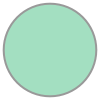

In [130]:
# Circle (using a buffer around a point)
point = shapely.Point((0,0))
point.buffer(1)